# Dry Bean Dataset — Exploratory Data Analysis & Model Training

This notebook performs end-to-end work for the Dry Bean multi-class classification problem:

1. Load and inspect the dataset
2. Exploratory Data Analysis (EDA)
3. Preprocessing (label encoding, train/test split, scaling)
4. Train **5 classification models**
5. Evaluate with 6 metrics (Accuracy, AUC, Precision, Recall, F1, MCC)
6. Compare models and visualise the best one

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, confusion_matrix, classification_report,
)

sns.set_style('whitegrid')
RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

## 2. Load the dataset

In [2]:
df = pd.read_csv('Dry_Bean_Dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610291.00,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638018.00,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.11,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645884.00,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620134.00,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

In [4]:
# Summary statistics of the numeric features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,2.546160e+05
Perimeter,13611.0,772910.982959,323884.750766,553.600000,676995.500000,772273.000000,955500.000000,1.921685e+06
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,7.388602e+02
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,4.601985e+02
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306e+00
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,9.114230e-01
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,2.632610e+05
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,5.693744e+02
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,8.661946e-01
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,9.946775e-01


In [5]:
# Missing values and duplicate check
print('Missing values per column:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Missing values per column:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Duplicate rows: 68


## 3. Exploratory Data Analysis

### 3.1 Target class distribution

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


/tmp/ipykernel_9023/3856309686.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


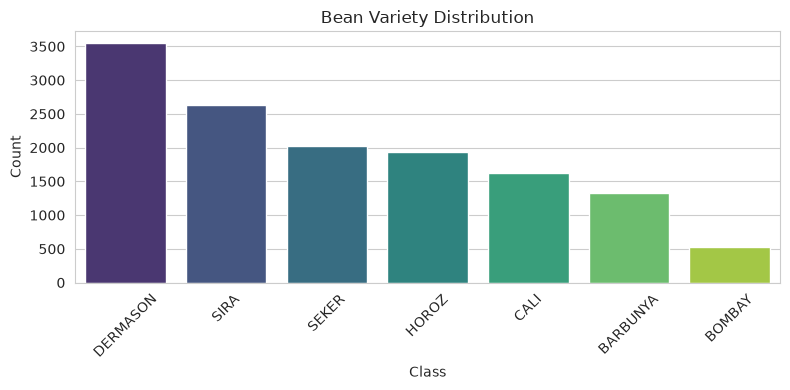

In [6]:
class_counts = df['Class'].value_counts()
print(class_counts)

plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Bean Variety Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The dataset is **imbalanced** - DERMASON is the most frequent class while BOMBAY is the rarest. We use stratified splitting to preserve these proportions.

### 3.2 Feature distributions

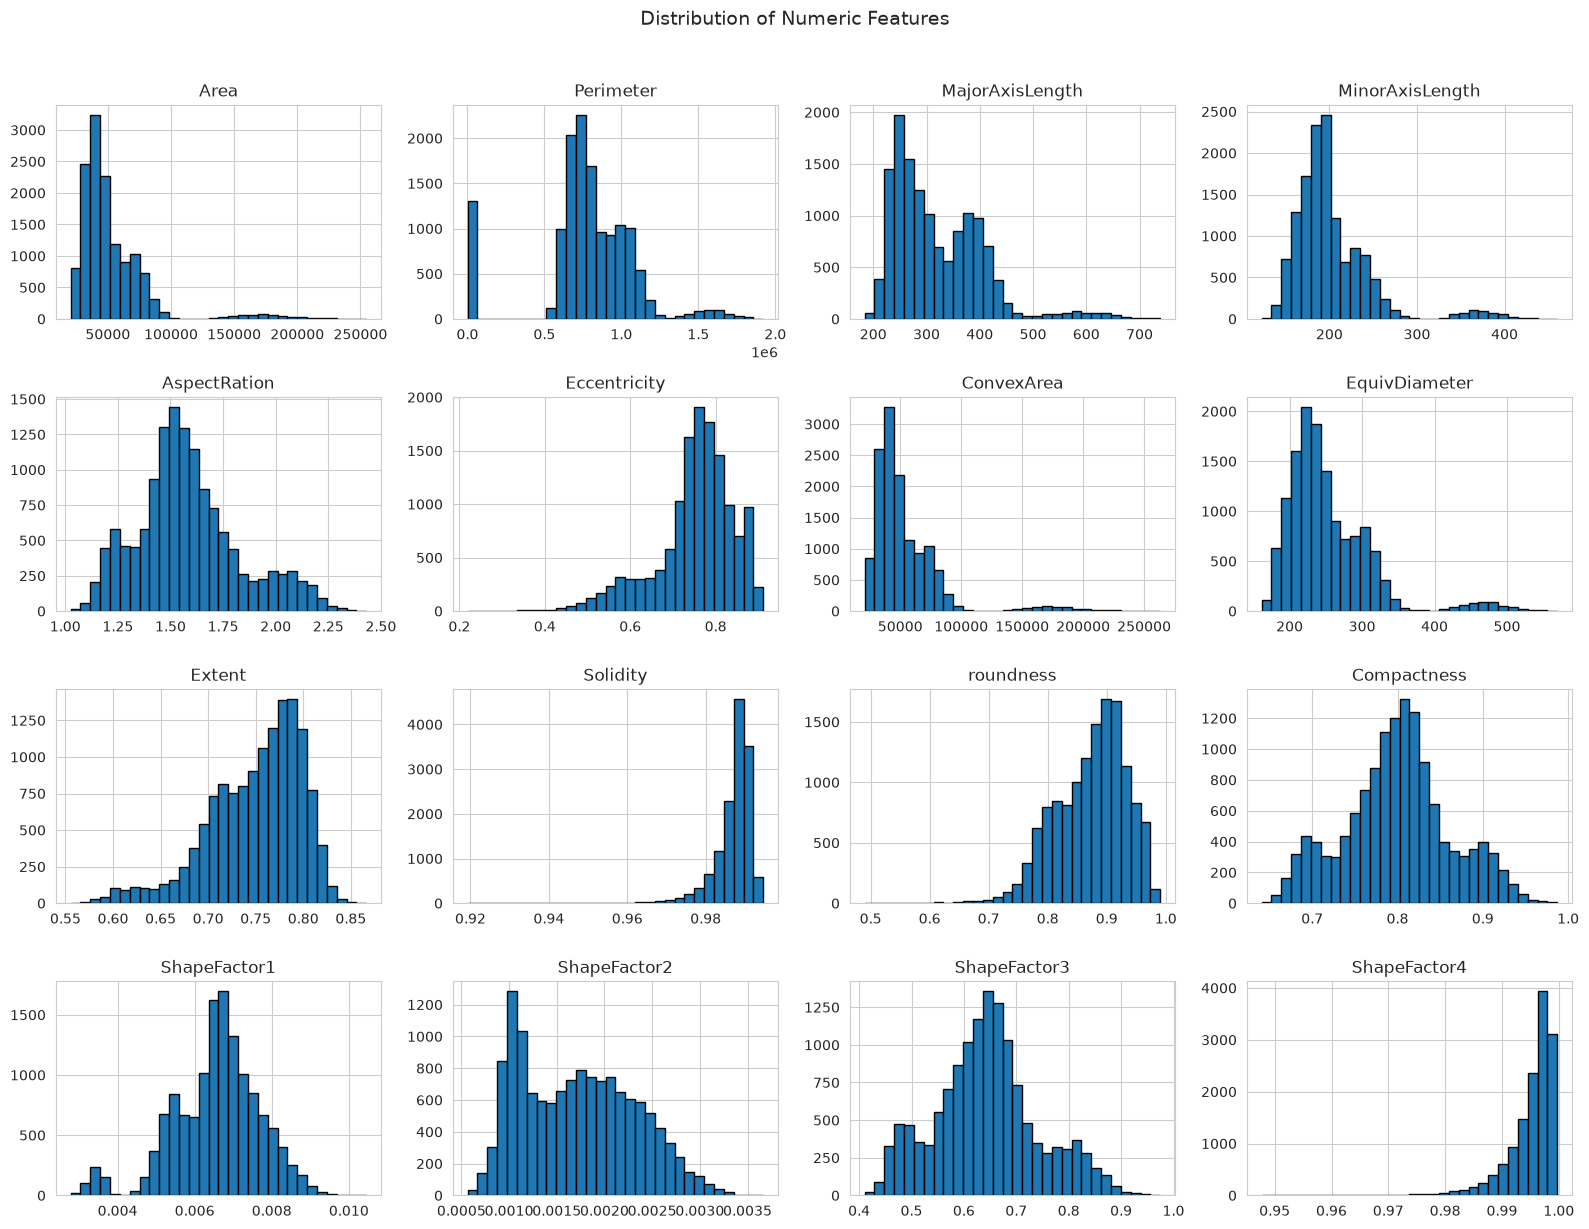

In [7]:
feature_cols = [c for c in df.columns if c != 'Class']

df[feature_cols].hist(figsize=(16, 12), bins=30, edgecolor='black')
plt.suptitle('Distribution of Numeric Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 3.3 Correlation heatmap

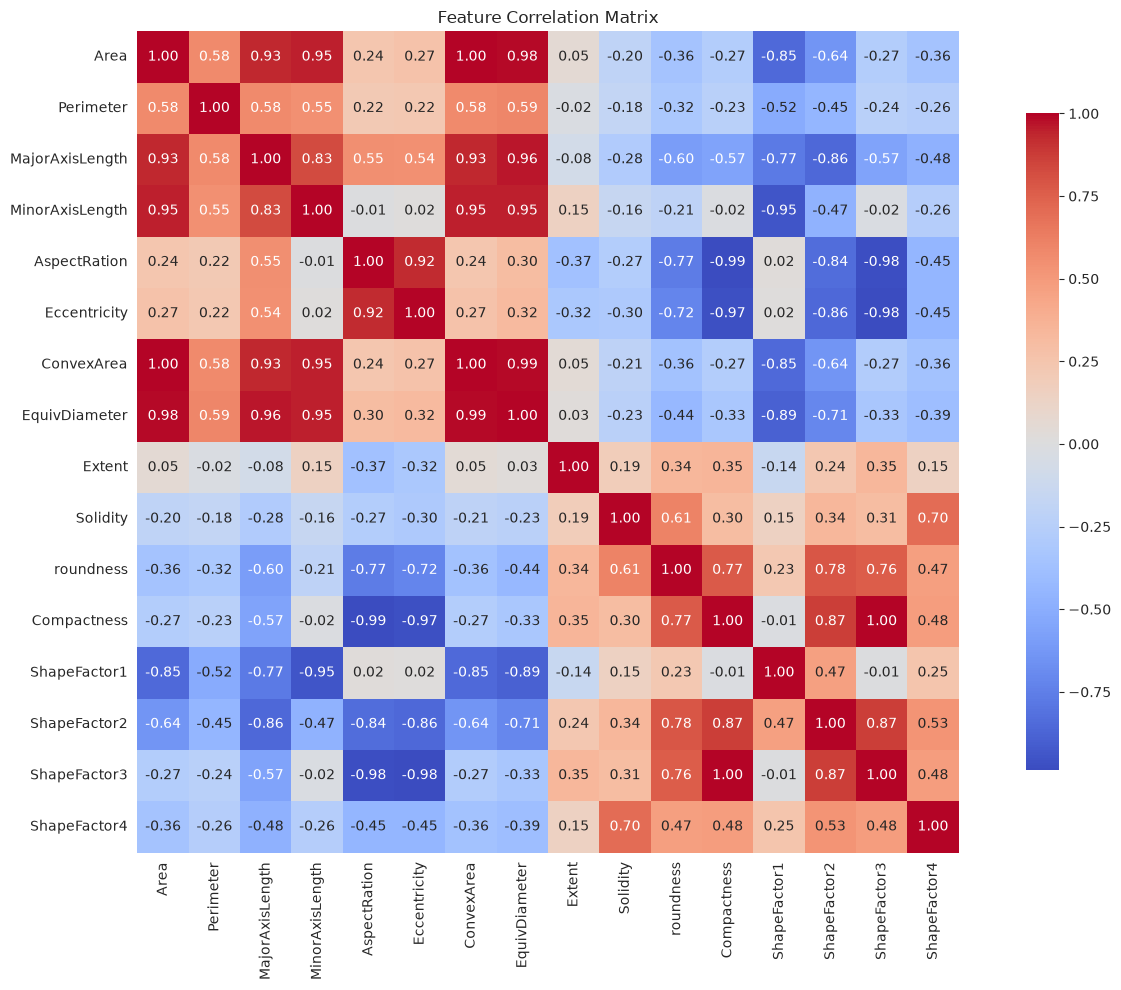

In [8]:
plt.figure(figsize=(14, 10))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

Several features are highly correlated (e.g. `Area`, `ConvexArea`, `EquivDiameter`, `Perimeter`) because they all describe bean size. This redundancy is expected for geometric measurements.

### 3.4 Feature separability by class (box plots)

/tmp/ipykernel_9023/977399205.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=feat, ax=ax, palette='Set2')
/tmp/ipykernel_9023/977399205.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=feat, ax=ax, palette='Set2')
/tmp/ipykernel_9023/977399205.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=feat, ax=ax, palette='Set2')
/tmp/ipykernel_9023/977399205.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign 

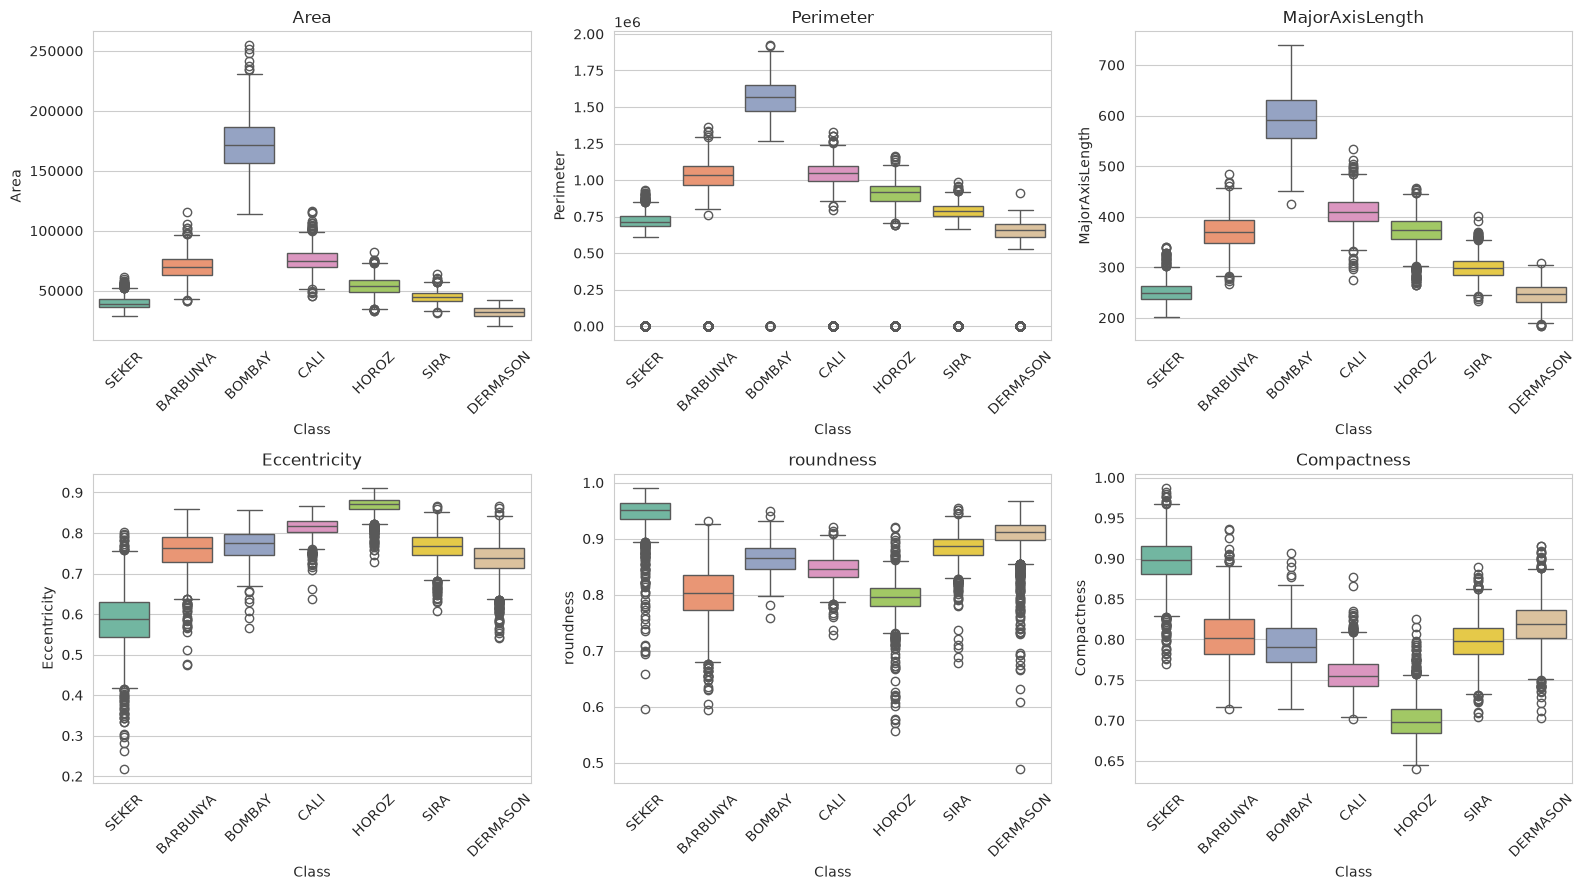

In [9]:
key_features = ['Area', 'Perimeter', 'MajorAxisLength', 'Eccentricity', 'roundness', 'Compactness']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.ravel(), key_features):
    sns.boxplot(data=df, x='Class', y=feat, ax=ax, palette='Set2')
    ax.set_title(feat)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [10]:
X = df.drop(columns=['Class'])
y_raw = df['Class']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = list(label_encoder.classes_)
class_ids = np.arange(len(class_names))
print('Classes:', class_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Train:', X_train.shape, ' Test:', X_test.shape)

Classes: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
Train: (10888, 16)  Test: (2723, 16)


## 5. Train the model

In [11]:
def make_pipeline(estimator):
    return Pipeline([('scaler', StandardScaler()), ('clf', estimator)])


def compute_metrics(model, X, y):
    y_pred = model.predict(X)
    proba = model.predict_proba(X)
    return {
        'Accuracy': accuracy_score(y, y_pred),
        'AUC': roc_auc_score(y, proba, multi_class='ovr', average='macro', labels=class_ids),
        'Precision': precision_score(y, y_pred, average='macro', zero_division=0),
        'Recall': recall_score(y, y_pred, average='macro', zero_division=0),
        'F1': f1_score(y, y_pred, average='macro', zero_division=0),
        'MCC': matthews_corrcoef(y, y_pred),
    }


# Collect fitted models and their TEST metrics for the final comparison table.
fitted = {}
results = []


def fit_and_report(name, model):
    """Fit a model, then show train vs test metrics to spot overfitting."""
    model.fit(X_train, y_train)
    fitted[name] = model
    train_m = compute_metrics(model, X_train, y_train)
    test_m = compute_metrics(model, X_test, y_test)
    results.append({'Model': name, **test_m})
    print(f'==== {name} ====')
    return pd.DataFrame({'Train': train_m, 'Test': test_m}).round(4)

In [12]:
# 1. Logistic Regression
log_reg = make_pipeline(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
fit_and_report('Logistic Regression', log_reg)

==== Logistic Regression ====


,Train,Test
Accuracy,0.9256,0.9210
AUC,0.9950,0.9947
Precision,0.9384,0.9353
Recall,0.9363,0.9322
F1,0.9373,0.9335
MCC,0.9101,0.9046


In [13]:
# 2. Decision Tree — regularized (max_depth / min_samples_leaf) to stop it
#    from memorising the training data (an unconstrained tree scores 1.0 on train).
decision_tree = make_pipeline(
    DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=RANDOM_STATE)
)
fit_and_report('Decision Tree', decision_tree)

==== Decision Tree ====


,Train,Test
Accuracy,0.9101,0.8928
AUC,0.9899,0.9831
Precision,0.9209,0.9044
Recall,0.9153,0.9009
F1,0.9169,0.9021
MCC,0.8916,0.8705


In [14]:
# 3. K-Nearest Neighbors
knn = make_pipeline(KNeighborsClassifier(n_neighbors=7))
fit_and_report('kNN', knn)

==== kNN ====


,Train,Test
Accuracy,0.9380,0.9115
AUC,0.9975,0.9853
Precision,0.9500,0.9273
Recall,0.9459,0.9214
F1,0.9478,0.9241
MCC,0.9250,0.8929


In [15]:
# 4. Naive Bayes (Gaussian)
naive_bayes = make_pipeline(GaussianNB())
fit_and_report('Naive Bayes', naive_bayes)

==== Naive Bayes ====


,Train,Test
Accuracy,0.8973,0.8979
AUC,0.9916,0.9916
Precision,0.9059,0.9116
Recall,0.9083,0.9094
F1,0.9068,0.9092
MCC,0.8762,0.8773


In [16]:
# 5. Random Forest (Ensemble) — regularized with max_depth, min_samples_leaf and
#    max_features='sqrt' so the forest generalises instead of memorising the train set.
random_forest = make_pipeline(
    RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=RANDOM_STATE,
    )
)
fit_and_report('Random Forest (Ensemble)', random_forest)

==== Random Forest (Ensemble) ====


,Train,Test
Accuracy,0.9578,0.9185
AUC,0.9987,0.9943
Precision,0.9657,0.9337
Recall,0.9624,0.9290
F1,0.9639,0.9312
MCC,0.9490,0.9014


## 6. Model comparison

In [17]:
comparison = pd.DataFrame(results).set_index('Model').round(4)
comparison

,Accuracy,AUC,Precision,Recall,F1,MCC
Model,,,,,,
Logistic Regression,0.9210,0.9947,0.9353,0.9322,0.9335,0.9046
Decision Tree,0.8928,0.9831,0.9044,0.9009,0.9021,0.8705
kNN,0.9115,0.9853,0.9273,0.9214,0.9241,0.8929
Naive Bayes,0.8979,0.9916,0.9116,0.9094,0.9092,0.8773
Random Forest (Ensemble),0.9185,0.9943,0.9337,0.9290,0.9312,0.9014


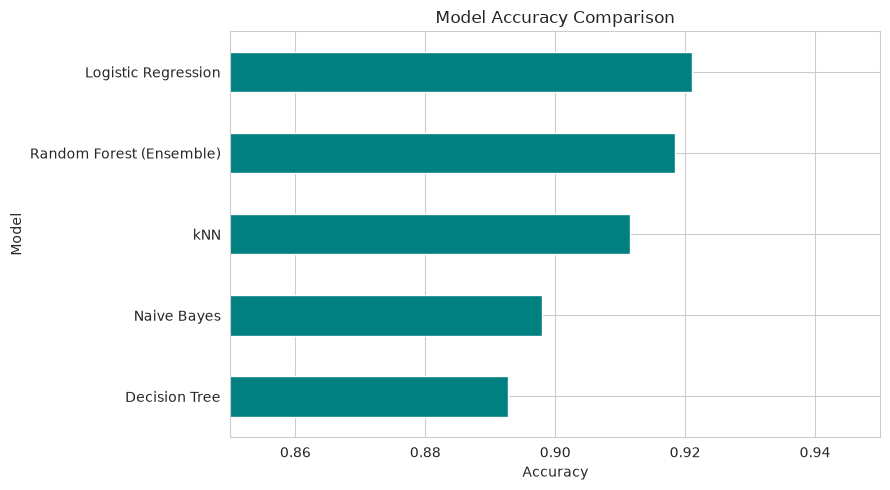

Best model by accuracy: Logistic Regression


In [18]:
comparison['Accuracy'].sort_values().plot(kind='barh', figsize=(9, 5), color='teal')
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.xlim(0.85, 0.95)
plt.tight_layout()
plt.show()

best_model_name = comparison['Accuracy'].idxmax()
print('Best model by accuracy:', best_model_name)

## 7. Confusion matrix & classification report (best model)

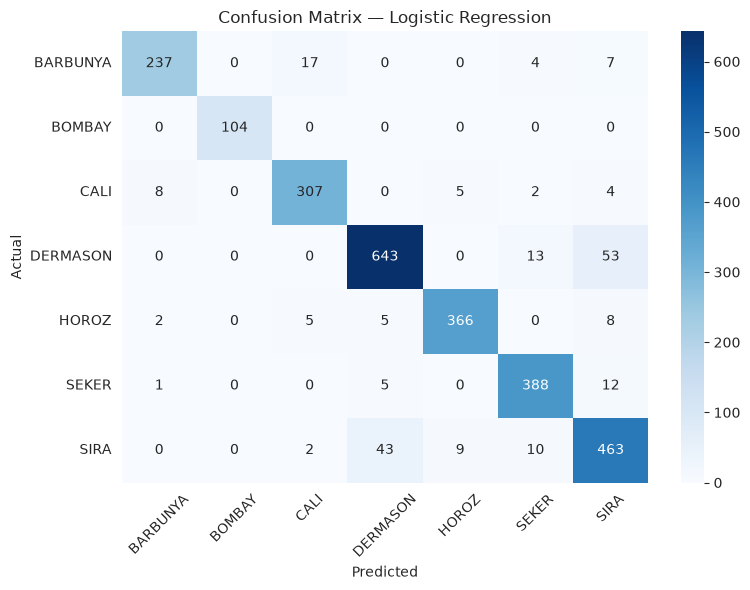

              precision    recall  f1-score   support

    BARBUNYA       0.96      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.93       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.93      0.96      0.94       406
        SIRA       0.85      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



In [19]:
best_model = fitted[best_model_name]
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=class_ids)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

## 8. Conclusion

- All five models achieve strong performance (~90%+ accuracy), confirming the bean varieties are well separated by their geometric features.
- **Logistic Regression** is the top performer, with the highest accuracy and best AUC while being the simplest/fastest, making it the recommended model.
- The single **Decision Tree** is the weakest (highest variance, poorly calibrated probabilities), while the **Random Forest** ensemble fixes this and is very robust.

The trained pipelines are saved to `model/*.joblib` by `model/train_models.py` and served through the Streamlit app (`app.py`).